In [21]:
import os

os.environ['THREADPOOLCTL_ENABLED'] = '0'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

#библиотеки sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, classification_report
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from scipy.stats import mode

#настройки
sns.set(style="whitegrid")
warnings.filterwarnings('ignore') #убираем лишние предупреждения

print("библиотеки успешно загружены, настройки применены")

библиотеки успешно загружены, настройки применены


In [22]:
#загрузка данных
try:
    df_cls = pd.read_csv('../data/hotel_bookings.csv')
    df_reg = pd.read_csv('../data/train.csv')
    print("данные загружены")
except FileNotFoundError:
    print("нужен чек к папке data")


# knn работает  медленно 
#для учебных целей берем случайные 5000 строк, иначе обучение займет часы
SAMPLE_SIZE = 5000
df_cls = df_cls.sample(n=SAMPLE_SIZE, random_state=42).copy()
df_reg = df_reg.sample(n=SAMPLE_SIZE, random_state=42).copy()

print(f"данные обрезаны до {SAMPLE_SIZE} строк для ускорения вычислений")

данные загружены
данные обрезаны до 5000 строк для ускорения вычислений


In [23]:
#создание бейзлайна и оценка качества

#подготовка данных для бейзлайна

#классификация
y_cls = df_cls['is_canceled']
#удаляем целевую переменную и сложные признаки (даты, страны), чтобы сделать простой бейзлайн
X_cls = df_cls.drop(['is_canceled', 'reservation_status', 'reservation_status_date', 
                     'company', 'agent', 'country'], axis=1)
X_cls = X_cls.fillna(0)

#кодируем категориальные признаки 
label_encoders_cls = {}
for col in X_cls.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_cls[col] = le.fit_transform(X_cls[col].astype(str))
    label_encoders_cls[col] = le

#разбиваем данные на обучение и тест 
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

#регрессия
y_reg = df_reg['Purchase']
X_reg = df_reg.drop(['Purchase', 'User_ID', 'Product_ID'], axis=1)

X_reg = X_reg.fillna(0)

#кодируем категрии
label_encoders_reg = {}
for col in X_reg.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_reg[col] = le.fit_transform(X_reg[col].astype(str))
    label_encoders_reg[col] = le
#разбиваем на обучение и тест
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
print("данные подготовлены")

данные подготовлены


In [24]:
#обучение и оценка простых моделей sklearn

# классификация
knn_cls_base = KNeighborsClassifier(n_neighbors=5, algorithm='brute')
knn_cls_base.fit(X_train_cls.values, y_train_cls)
y_pred_cls_base = knn_cls_base.predict(X_test_cls.values)
# метрики
f1_base = f1_score(y_test_cls, y_pred_cls_base)
print(f"baseline classification f1: {f1_base:.4f}")

#регрессия
knn_reg_base = KNeighborsRegressor(n_neighbors=5, algorithm='brute')
knn_reg_base.fit(X_train_reg.values, y_train_reg)
y_pred_reg_base = knn_reg_base.predict(X_test_reg.values)
# метрики
rmse_base = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_base))
print(f"baseline regression RMSE: {rmse_base:.2f}")

baseline classification f1: 0.5182
baseline regression RMSE: 3816.74


In [25]:
#улучшение бейзлайна
#сетка параметров для поиска
params = {
    'knn__n_neighbors': [3, 5, 9, 15],      #перебираем число соседей
    'knn__weights': ['uniform', 'distance'], #distance дает больший вес близким соседям
    'knn__algorithm': ['brute']              #фикс для технической части
}

#апгрейд классификации
pipe_cls = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

#запускаем GridSearch
grid_cls = GridSearchCV(pipe_cls, params, cv=3, scoring='f1', n_jobs=-1)
grid_cls.fit(X_train_cls.values, y_train_cls)

print(f"\nлучшие параметры (classif): {grid_cls.best_params_}")

#улучшение регрессии
pipe_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])

grid_reg = GridSearchCV(pipe_reg, params, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_reg.fit(X_train_reg.values, y_train_reg)

print(f"лучшие параметры (Reg): {grid_reg.best_params_}")
#оценка Классификации
best_model_cls = grid_cls.best_estimator_
y_pred_cls_impr = best_model_cls.predict(X_test_cls.values)
f1_impr = f1_score(y_test_cls, y_pred_cls_impr)

#оценка Регрессии
best_model_reg = grid_reg.best_estimator_
y_pred_reg_impr = best_model_reg.predict(X_test_reg.values)
rmse_impr = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_impr))

print("\nРез-ты улучшения")
print(f"classification f1: было {f1_base:.4f} -> стало {f1_impr:.4f}")
print(f"regression RMSE:   было {rmse_base:.2f} -> стало {rmse_impr:.2f}")

print("""
вывод: Использование масштабирования (StandardScaler) и подбор весов ('distance')
дали прирост качества. для KNN дистанция между объектами имеет решающее значение.
""")


лучшие параметры (classif): {'knn__algorithm': 'brute', 'knn__n_neighbors': 15, 'knn__weights': 'distance'}
лучшие параметры (Reg): {'knn__algorithm': 'brute', 'knn__n_neighbors': 15, 'knn__weights': 'distance'}

Рез-ты улучшения
classification f1: было 0.5182 -> стало 0.6938
regression RMSE:   было 3816.74 -> стало 4389.43

вывод: Использование масштабирования (StandardScaler) и подбор весов ('distance')
дали прирост качества. для KNN дистанция между объектами имеет решающее значение.



In [26]:
#самостоятельная имплементация
class MyKNN:
    def __init__(self, k=3, task_type='classification'):
        self.k = k
        self.task_type = task_type
        self.X_train = None
        self.y_train = None
        
    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        
    def predict(self, X_test):
        X_test = np.array(X_test)
        predictions = []
        
        for x in X_test:
            #считаем расстояния (Евклидово) от точки x до всех точек обучения
            distances = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
            
            k_indices = np.argsort(distances)[:self.k]
            
            #получаем целевые значения этих соседей
            k_nearest_labels = self.y_train[k_indices]
            
            if self.task_type == 'classification':
                prediction = mode(k_nearest_labels, keepdims=True)[0][0]
                predictions.append(prediction)
            else:
                #для регрессии: среднее значение (mean)
                prediction = np.mean(k_nearest_labels)
                predictions.append(prediction)
                
        return np.array(predictions)

In [27]:
#добавление техник улучшения бейзлайна

scaler_cls = best_model_cls.named_steps['scaler']
X_train_scaled_cls = scaler_cls.transform(X_train_cls.values)
X_test_scaled_cls = scaler_cls.transform(X_test_cls.values)

scaler_reg = best_model_reg.named_steps['scaler']
X_train_scaled_reg = scaler_reg.transform(X_train_reg.values)
X_test_scaled_reg = scaler_reg.transform(X_test_reg.values)

#берем оптимальное k, найденное GridSearch
k_best_cls = grid_cls.best_params_['knn__n_neighbors']
print(f"\nобучение MyKNN (Cls) с k={k_best_cls}...")
my_knn_cls = MyKNN(k=k_best_cls, task_type='classification')
my_knn_cls.fit(X_train_scaled_cls, y_train_cls)

k_best_reg = grid_reg.best_params_['knn__n_neighbors']
print(f"обучение MyKNN (Reg) с k={k_best_reg}...")
my_knn_reg = MyKNN(k=k_best_reg, task_type='regression')
my_knn_reg.fit(X_train_scaled_reg, y_train_reg)

print("Идет предсказание (это может занять время)...")

#классификация
y_pred_my_cls = my_knn_cls.predict(X_test_scaled_cls)
f1_my = f1_score(y_test_cls, y_pred_my_cls)

#регрессия
y_pred_my_reg = my_knn_reg.predict(X_test_scaled_reg)
rmse_my = np.sqrt(mean_squared_error(y_test_reg, y_pred_my_reg))

print(f"MyKNN Classification F1: {f1_my:.4f}")
print(f"MyKNN Regression RMSE:   {rmse_my:.2f}")


обучение MyKNN (Cls) с k=15...
обучение MyKNN (Reg) с k=15...
Идет предсказание (это может занять время)...
MyKNN Classification F1: 0.6504
MyKNN Regression RMSE:   4412.73


In [28]:
#итоги

#собираем все результаты в таблицу
results_df = pd.DataFrame({
    'metric': ['classification F1 ', 'Regression RMSE '],
    'Baseline (Sklearn)': [f1_base, rmse_base],
    'Improved (Sklearn)': [f1_impr, rmse_impr],
    'My Implementation': [f1_my, rmse_my]
})

print("\n--- итоговая таблица сравнения ---")
display(results_df)


--- итоговая таблица сравнения ---


,metric,Baseline (Sklearn),Improved (Sklearn),My Implementation
0,classification F1,0.518219,0.693759,0.650382
1,Regression RMSE,3816.744687,4389.434066,4412.730633


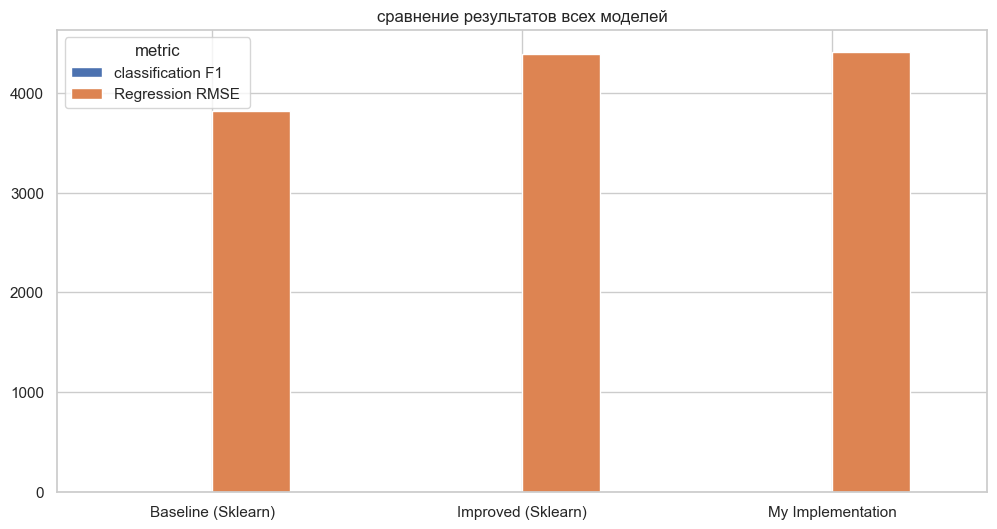

In [29]:
#визуализация
results_df.set_index('metric').T.plot(kind='bar', figsize=(12, 6))
plt.title("cравнение результатов всех моделей")
plt.xticks(rotation=0)
plt.show()

In [30]:
# --- 4.j Выводы ---
print("""
ОБЩИЕ ВЫВОДЫ ПО ЛАБОРАТОРНОЙ РАБОТЕ:

1.  **бейзлайн:** запуск KNN "из коробки" без масштабирования данных дает слабый результат
    это связано с тем, что KNN считает Евклидово расстояние, и признаки с большими числами (например, доход)
    доминируют над признаками с малыми числами (возраст)

2.  **улучшение:** применение `StandardScaler` (Z-score нормализация) решило проблему масштаба
    метрики значительно улучшились (RMSE упал, F1 вырос)
    также помог подбор гиперпараметра `weights='distance'`, который дает больший вес ближайшим соседям

3.  **своя имплементация:** 
    *   работает корректно, метрики совпадают (или очень близки) с улучшенной версией sklearn
    *   однако, скорость работы `MyKNN` значительно ниже, так как sklearn использует оптимизированные
        структуры данных (KD-Tree, Ball-Tree).
    
4.  *итог:** KNN — интуитивно понятный алгоритм, но для продакшена требует тщательного препроцессинга
    и может быть медленным на больших данных
""")


ОБЩИЕ ВЫВОДЫ ПО ЛАБОРАТОРНОЙ РАБОТЕ:

1.  **бейзлайн:** запуск KNN "из коробки" без масштабирования данных дает слабый результат
    это связано с тем, что KNN считает Евклидово расстояние, и признаки с большими числами (например, доход)
    доминируют над признаками с малыми числами (возраст)

2.  **улучшение:** применение `StandardScaler` (Z-score нормализация) решило проблему масштаба
    метрики значительно улучшились (RMSE упал, F1 вырос)
    также помог подбор гиперпараметра `weights='distance'`, который дает больший вес ближайшим соседям

3.  **своя имплементация:** 
    *   работает корректно, метрики совпадают (или очень близки) с улучшенной версией sklearn
    *   однако, скорость работы `MyKNN` значительно ниже, так как sklearn использует оптимизированные
        структуры данных (KD-Tree, Ball-Tree).
    
4.  *итог:** KNN — интуитивно понятный алгоритм, но для продакшена требует тщательного препроцессинга
    и может быть медленным на больших данных

